# Лабораторная №4

1. `ResNet18`, предобученная на `ImageNet`.
2. `DINOv2 ViT-S/14`, предобученная self-supervised на `LVD-142M` (то есть не на `ImageNet`).
3. Собственная компактная `CNN`, обучаемая с нуля.


In [56]:
import os
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(".mplconfig").resolve()))
os.environ.setdefault("TORCH_HOME", str(Path(".cache/torch").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["TORCH_HOME"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.set_float32_matmul_precision("medium")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
device


Using device: mps


device(type='mps')

## 1. Подготовка и разбиение `DVM-CAR`

Используется quality-checked front-view subset, который уже лежит в `lab4/data/confirmed_fronts`.

В этой версии датасета путь имеет вид `Brand/Year/filename.jpg`, а цвет извлекается из имени файла формата `Brand$$Model$$Year$$Color$$...jpg`.


In [57]:
@dataclass
class Config:
    data_dir: Path = Path("data/confirmed_fronts")
    image_size: int = 168
    batch_size: int = 32
    transfer_epochs: int = 3
    scratch_epochs: int = 5
    transfer_lr: float = 1e-3
    scratch_lr: float = 5e-4
    weight_decay: float = 1e-4
    min_samples_per_class: int = 30
    val_size: float = 0.15
    test_size: float = 0.15
    num_workers: int = 0
    log_every_batches: int = 200

config = Config()
config


Config(data_dir=PosixPath('data/confirmed_fronts'), image_size=168, batch_size=32, transfer_epochs=3, scratch_epochs=5, transfer_lr=0.001, scratch_lr=0.0005, weight_decay=0.0001, min_samples_per_class=30, val_size=0.15, test_size=0.15, num_workers=0, log_every_batches=200)

In [58]:
ALLOWED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def normalize_label(label: str) -> str:
    return label.strip().lower().replace(" ", "_")

def extract_color_from_filename(image_path: Path) -> str | None:
    parts = image_path.stem.split("$$")
    if len(parts) < 4:
        return None
    return normalize_label(parts[3])

def scan_dvm_color_samples(data_dir: Path):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        raise FileNotFoundError(
            f"Не найдена папка {data_dir}. Проверьте, что front-view subset распакован в lab4/data/confirmed_fronts."
        )

    records = []
    skipped = 0
    for image_path in sorted(data_dir.rglob("*")):
        if not image_path.is_file() or image_path.suffix.lower() not in ALLOWED_EXTENSIONS:
            continue
        color_name = extract_color_from_filename(image_path)
        if color_name is None:
            skipped += 1
            continue
        records.append((image_path, color_name))

    if not records:
        raise RuntimeError("В указанной папке не найдено изображений с ожидаемой структурой confirmed_fronts/Brand/Year/*.jpg")

    counts = Counter(label for _, label in records)
    valid_labels = {label for label, count in counts.items() if count >= config.min_samples_per_class}
    filtered_records = [(path, label) for path, label in records if label in valid_labels]
    filtered_counts = Counter(label for _, label in filtered_records)
    return filtered_records, counts, filtered_counts, skipped

all_records, raw_counts, filtered_counts, skipped_files = scan_dvm_color_samples(config.data_dir)
print(f"Всего изображений после фильтрации редких цветов: {len(all_records)}")
print(f"Число классов после фильтрации: {len(filtered_counts)}")
print(f"Пропущено файлов с неожиданным именем: {skipped_files}")
sorted(filtered_counts.items(), key=lambda x: (-x[1], x[0]))[:15]


Всего изображений после фильтрации редких цветов: 61755
Число классов после фильтрации: 17
Пропущено файлов с неожиданным именем: 0


[('black', 14317),
 ('grey', 9474),
 ('white', 9395),
 ('blue', 8483),
 ('silver', 7770),
 ('red', 6095),
 ('unlisted', 1516),
 ('brown', 911),
 ('green', 777),
 ('yellow', 667),
 ('beige', 600),
 ('orange', 559),
 ('purple', 362),
 ('bronze', 329),
 ('gold', 217)]

In [59]:
paths = [str(path) for path, _ in all_records]
labels = [label for _, label in all_records]

test_ratio_from_temp = config.test_size / (config.val_size + config.test_size)

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths, labels, test_size=(config.val_size + config.test_size), stratify=labels, random_state=SEED
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=test_ratio_from_temp, stratify=temp_labels, random_state=SEED
)

class_names = sorted(set(train_labels))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

def summarize_split(split_name, split_labels):
    counts = Counter(split_labels)
    print(f"{split_name}: {len(split_labels)} изображений")
    for name, count in sorted(counts.items(), key=lambda x: (-x[1], x[0]))[:10]:
        print(f"  {name:>12}: {count}")

summarize_split("Train", train_labels)
summarize_split("Val", val_labels)
summarize_split("Test", test_labels)


Train: 43228 изображений
         black: 10022
          grey: 6632
         white: 6576
          blue: 5938
        silver: 5439
           red: 4267
      unlisted: 1061
         brown: 638
         green: 544
        yellow: 467
Val: 9263 изображений
         black: 2147
          grey: 1421
         white: 1409
          blue: 1272
        silver: 1165
           red: 914
      unlisted: 227
         brown: 136
         green: 117
        yellow: 100
Test: 9264 изображений
         black: 2148
          grey: 1421
         white: 1410
          blue: 1273
        silver: 1166
           red: 914
      unlisted: 228
         brown: 137
         green: 116
        yellow: 100


In [60]:
class DVMColorDataset(Dataset):
    def __init__(self, paths, labels, class_to_idx, transform=None):
        self.paths = list(paths)
        self.labels = [class_to_idx[label] for label in labels]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):
        image = Image.open(self.paths[index]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, self.labels[index]

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(config.image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((config.image_size, config.image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_dataset = DVMColorDataset(train_paths, train_labels, class_to_idx, train_transform)
val_dataset = DVMColorDataset(val_paths, val_labels, class_to_idx, eval_transform)
test_dataset = DVMColorDataset(test_paths, test_labels, class_to_idx, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers)

len(train_dataset), len(val_dataset), len(test_dataset), len(class_names)


(43228, 9263, 9264, 17)

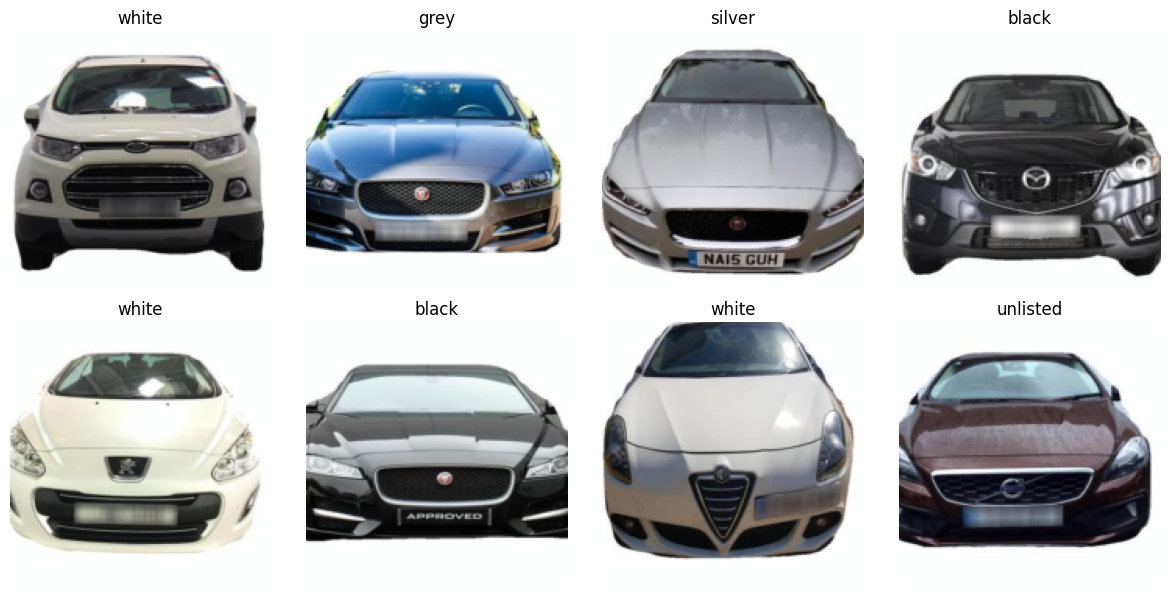

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
for ax, idx in zip(axes, np.random.choice(len(train_dataset), size=min(8, len(train_dataset)), replace=False)):
    image_tensor, label_idx = train_dataset[idx]
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = np.clip(image_np * np.array(imagenet_std) + np.array(imagenet_mean), 0, 1)
    ax.imshow(image_np)
    ax.set_title(idx_to_class[label_idx])
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Метрика `F1_macro`


In [62]:
def make_weighted_criterion(train_labels, class_to_idx):
    counts = Counter(train_labels)
    weights = []
    total = sum(counts.values())
    num_classes = len(class_to_idx)
    for class_name in sorted(class_to_idx):
        weights.append(total / (num_classes * counts[class_name]))
    return nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float32, device=device))

criterion = make_weighted_criterion(train_labels, class_to_idx)

def evaluate_model(model, loader, criterion):
    model.eval()
    losses = []
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            preds = logits.argmax(dim=1)
            losses.append(loss.item())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
    return {
        "loss": float(np.mean(losses)),
        "accuracy": accuracy_score(all_targets, all_preds),
        "f1_macro": f1_score(all_targets, all_preds, average="macro"),
        "preds": np.array(all_preds),
        "targets": np.array(all_targets),
    }

def fit_model(model, train_loader, val_loader, optimizer, criterion, epochs, scheduler=None, log_every_batches=50):
    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_f1 = -1.0

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        train_preds = []
        train_targets = []

        total_batches = len(train_loader)
        for batch_idx, (images, targets) in enumerate(train_loader, start=1):
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            train_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
            train_targets.extend(targets.detach().cpu().numpy())

            if batch_idx == 1 or batch_idx % log_every_batches == 0 or batch_idx == total_batches:
                print(
                    f"epoch {epoch:02d}/{epochs} | batch {batch_idx:04d}/{total_batches:04d} | "
                    f"loss={loss.item():.4f}"
                )

        train_loss = float(np.mean(train_losses))
        train_acc = accuracy_score(train_targets, train_preds)
        train_f1 = f1_score(train_targets, train_preds, average="macro")
        val_metrics = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_metrics["f1_macro"])

        if scheduler is not None:
            scheduler.step()

        if val_metrics["f1_macro"] > best_val_f1:
            best_val_f1 = val_metrics["f1_macro"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"epoch {epoch:02d}/{epochs} done | "
            f"train_loss={train_loss:.4f} train_f1={train_f1:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} val_f1={val_metrics['f1_macro']:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

def plot_history(history, title_prefix=""):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title(f"{title_prefix}Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["train_f1"], label="train macro F1")
    axes[1].plot(epochs, history["val_f1"], label="val macro F1")
    axes[1].set_title(f"{title_prefix}Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


## 3. Дообучение `ResNet18`, предобученной на `ImageNet`

Trainable parameters in ResNet18 head: 8,721
epoch 01/3 | batch 0001/1351 | loss=2.9387
epoch 01/3 | batch 0200/1351 | loss=1.5956
epoch 01/3 | batch 0400/1351 | loss=2.0792
epoch 01/3 | batch 0600/1351 | loss=2.2790
epoch 01/3 | batch 0800/1351 | loss=1.3657
epoch 01/3 | batch 1000/1351 | loss=1.1391
epoch 01/3 | batch 1200/1351 | loss=2.2435
epoch 01/3 | batch 1351/1351 | loss=1.0255
epoch 01/3 done | train_loss=1.9090 train_f1=0.3232 | val_loss=1.6893 val_f1=0.3888
epoch 02/3 | batch 0001/1351 | loss=1.2253
epoch 02/3 | batch 0200/1351 | loss=0.7514
epoch 02/3 | batch 0400/1351 | loss=1.4847
epoch 02/3 | batch 0600/1351 | loss=0.9477
epoch 02/3 | batch 0800/1351 | loss=1.5548
epoch 02/3 | batch 1000/1351 | loss=1.3801
epoch 02/3 | batch 1200/1351 | loss=1.5059
epoch 02/3 | batch 1351/1351 | loss=1.0206
epoch 02/3 done | train_loss=1.6213 train_f1=0.3710 | val_loss=1.6086 val_f1=0.4314
epoch 03/3 | batch 0001/1351 | loss=0.5778
epoch 03/3 | batch 0200/1351 | loss=1.5498
epoch 03/3 | 

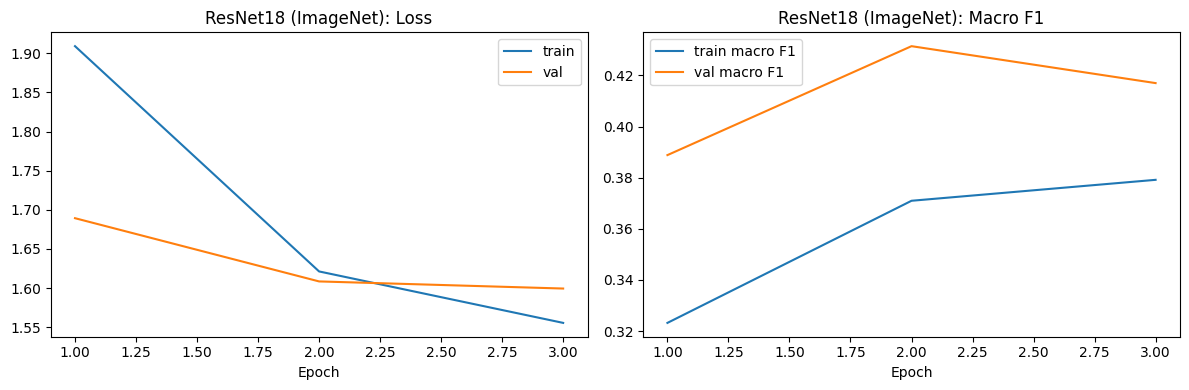

(0.4259605477246615, 0.6089162348877375)

In [63]:
def build_resnet18_classifier(num_classes: int, freeze_backbone: bool = True):
    weights = models.ResNet18_Weights.DEFAULT
    model = models.resnet18(weights=weights)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

resnet18_model = build_resnet18_classifier(len(class_names), freeze_backbone=True).to(device)
resnet18_trainable_params = [param for param in resnet18_model.parameters() if param.requires_grad]
print(f"Trainable parameters in ResNet18 head: {sum(param.numel() for param in resnet18_trainable_params):,}")
resnet18_optimizer = torch.optim.AdamW(resnet18_trainable_params, lr=config.transfer_lr, weight_decay=config.weight_decay)
resnet18_history = fit_model(
    resnet18_model, train_loader, val_loader, resnet18_optimizer, criterion,
    epochs=config.transfer_epochs, log_every_batches=config.log_every_batches
)
plot_history(resnet18_history, title_prefix="ResNet18 (ImageNet): ")
resnet18_test_metrics = evaluate_model(resnet18_model, test_loader, criterion)
resnet18_test_metrics["f1_macro"], resnet18_test_metrics["accuracy"]


## 4. Дообучение `DINOv2 ViT-S/14`, предобученной на `LVD-142M`

`DINOv2` обучена self-supervised на большом корпусе `LVD-142M`, поэтому это хороший пример сильного визуального backbone, предобученного не на `ImageNet`, это позволяет корректно выполнить условие сравнения моделей с разными источниками предобучения и проверить, насколько универсальные признаки, полученные вне ImageNet, полезны для классификации цветов автомобилей

Using cache found in /Users/nikitagerasimov/Desktop/Study/6 semestr/CV/CV-GerasimovNS-M3303/lab4/.cache/torch/hub/facebookresearch_dinov2_main


epoch 01/3 | batch 0001/1351 | loss=3.8447
epoch 01/3 | batch 0200/1351 | loss=2.5472
epoch 01/3 | batch 0400/1351 | loss=1.8539
epoch 01/3 | batch 0600/1351 | loss=1.4221
epoch 01/3 | batch 0800/1351 | loss=1.0336
epoch 01/3 | batch 1000/1351 | loss=2.0661
epoch 01/3 | batch 1200/1351 | loss=1.3846
epoch 01/3 | batch 1351/1351 | loss=1.2296
epoch 01/3 done | train_loss=1.8785 train_f1=0.3185 | val_loss=1.6697 val_f1=0.3952
epoch 02/3 | batch 0001/1351 | loss=2.1585
epoch 02/3 | batch 0200/1351 | loss=1.6529
epoch 02/3 | batch 0400/1351 | loss=1.4457
epoch 02/3 | batch 0600/1351 | loss=2.8949
epoch 02/3 | batch 0800/1351 | loss=1.5760
epoch 02/3 | batch 1000/1351 | loss=1.7764
epoch 02/3 | batch 1200/1351 | loss=1.3327
epoch 02/3 | batch 1351/1351 | loss=1.6373
epoch 02/3 done | train_loss=1.5291 train_f1=0.3907 | val_loss=1.7222 val_f1=0.3900
epoch 03/3 | batch 0001/1351 | loss=1.0710
epoch 03/3 | batch 0200/1351 | loss=1.3958
epoch 03/3 | batch 0400/1351 | loss=1.0207
epoch 03/3 | ba

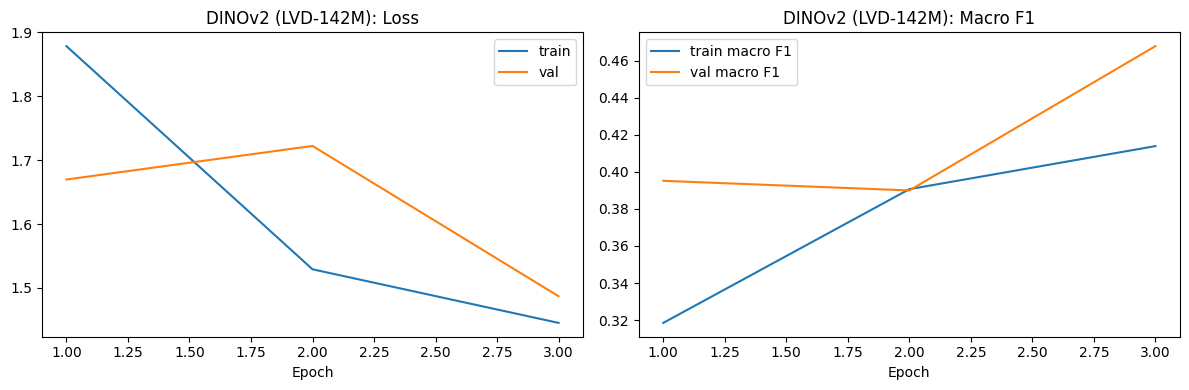

(0.4593256853558272, 0.6743307426597582)

In [64]:
class DINOv2LinearHead(nn.Module):
    def __init__(self, backbone, feature_dim, num_classes, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(feature_dim, num_classes)
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        if isinstance(features, (tuple, list)):
            features = features[0]
        if features.ndim > 2:
            features = features.mean(dim=1)
        return self.classifier(features)

dinov2_backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dinov2_backbone.eval()
with torch.no_grad():
    dummy = torch.zeros(1, 3, config.image_size, config.image_size)
    dummy_out = dinov2_backbone(dummy)
    if isinstance(dummy_out, (tuple, list)):
        dummy_out = dummy_out[0]
    if dummy_out.ndim > 2:
        dummy_out = dummy_out.mean(dim=1)
    dinov2_feature_dim = int(dummy_out.shape[-1])

dinov2_model = DINOv2LinearHead(
    dinov2_backbone, dinov2_feature_dim, len(class_names), freeze_backbone=True
).to(device)
dinov2_optimizer = torch.optim.AdamW(dinov2_model.parameters(), lr=1e-3, weight_decay=config.weight_decay)
dinov2_history = fit_model(
    dinov2_model, train_loader, val_loader, dinov2_optimizer, criterion,
    epochs=config.transfer_epochs, log_every_batches=config.log_every_batches
)
plot_history(dinov2_history, title_prefix="DINOv2 (LVD-142M): ")
dinov2_test_metrics = evaluate_model(dinov2_model, test_loader, criterion)
dinov2_test_metrics["f1_macro"], dinov2_test_metrics["accuracy"]


## 5. Собственная `CNN`, обучаемая с нуля

Для классификации цветов не требуется очень глубокая архитектура, тк основной сигнал содержится в цветовых распределениях и относительно простых локальных паттернах поверхности машины. Поэтому выбрана компактная `CNN` из нескольких свёрточных блоков с `BatchNorm`, `ReLU`, `MaxPool` и `GlobalAveragePooling`.

Такой вариант:

- существенно легче трансферных моделей, засчет того, что эта CNN маленькая по числу параметров и по вычислениям
- обучается с нуля за разумное время;
- даёт честную базовую точку сравнения без внешнего предобучения.


epoch 01/5 | batch 0001/1351 | loss=2.9290
epoch 01/5 | batch 0200/1351 | loss=1.9667
epoch 01/5 | batch 0400/1351 | loss=1.6196
epoch 01/5 | batch 0600/1351 | loss=1.9202
epoch 01/5 | batch 0800/1351 | loss=2.2848
epoch 01/5 | batch 1000/1351 | loss=2.4222
epoch 01/5 | batch 1200/1351 | loss=1.8308
epoch 01/5 | batch 1351/1351 | loss=2.4426
epoch 01/5 done | train_loss=2.0613 train_f1=0.2601 | val_loss=1.8131 val_f1=0.3182
epoch 02/5 | batch 0001/1351 | loss=1.5114
epoch 02/5 | batch 0200/1351 | loss=1.6211
epoch 02/5 | batch 0400/1351 | loss=1.6103
epoch 02/5 | batch 0600/1351 | loss=2.3396
epoch 02/5 | batch 0800/1351 | loss=1.4101
epoch 02/5 | batch 1000/1351 | loss=1.2577
epoch 02/5 | batch 1200/1351 | loss=1.7077
epoch 02/5 | batch 1351/1351 | loss=2.1795
epoch 02/5 done | train_loss=1.8159 train_f1=0.3136 | val_loss=1.7806 val_f1=0.3301
epoch 03/5 | batch 0001/1351 | loss=1.9914
epoch 03/5 | batch 0200/1351 | loss=1.1611
epoch 03/5 | batch 0400/1351 | loss=2.2454
epoch 03/5 | ba

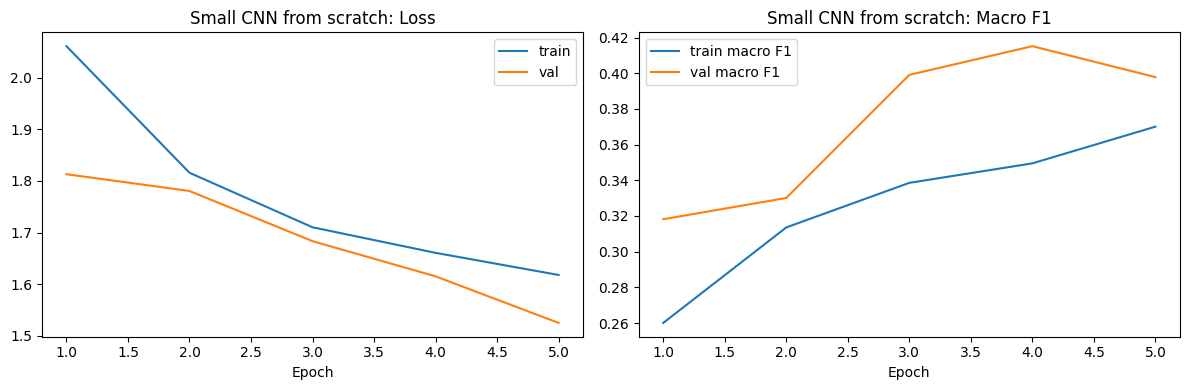

(0.41908037912595997, 0.6704447322970639)

In [65]:
class SmallColorCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

scratch_model = SmallColorCNN(len(class_names)).to(device)
scratch_optimizer = torch.optim.AdamW(scratch_model.parameters(), lr=config.scratch_lr, weight_decay=config.weight_decay)
scratch_history = fit_model(
    scratch_model, train_loader, val_loader, scratch_optimizer, criterion,
    epochs=config.scratch_epochs, log_every_batches=config.log_every_batches
)
plot_history(scratch_history, title_prefix="Small CNN from scratch: ")
scratch_test_metrics = evaluate_model(scratch_model, test_loader, criterion)
scratch_test_metrics["f1_macro"], scratch_test_metrics["accuracy"]


## 6. Итоговое сравнение моделей


In [66]:
results = {
    "ResNet18 / ImageNet": resnet18_test_metrics,
    "DINOv2 / LVD-142M": dinov2_test_metrics,
    "Custom CNN / scratch": scratch_test_metrics,
}

header = f"{'Model':<24} | {'Loss':>8} | {'Accuracy':>8} | {'F1_macro':>8}"
print(header)
print("-" * len(header))
for name, metrics in sorted(results.items(), key=lambda item: item[1]["f1_macro"], reverse=True):
    print(f"{name:<24} | {metrics['loss']:.4f} | {metrics['accuracy']:.4f} | {metrics['f1_macro']:.4f}")


Model                    |     Loss | Accuracy | F1_macro
---------------------------------------------------------
DINOv2 / LVD-142M        | 1.4295 | 0.6743 | 0.4593
ResNet18 / ImageNet      | 1.5767 | 0.6089 | 0.4260
Custom CNN / scratch     | 1.5829 | 0.6704 | 0.4191


In [67]:
best_model_name, best_metrics = max(results.items(), key=lambda item: item[1]["f1_macro"])
transfer_best = max(
    [(name, metrics) for name, metrics in results.items() if "scratch" not in name.lower()],
    key=lambda item: item[1]["f1_macro"]
)
scratch_metrics = results["Custom CNN / scratch"]

print(f"Лучшая модель: {best_model_name}")
print(f"F1_macro = {best_metrics['f1_macro']:.4f}")
print(f"Accuracy = {best_metrics['accuracy']:.4f}")
print(f"Accuracy - F1_macro = {best_metrics['accuracy'] - best_metrics['f1_macro']:.4f}")
print(f"Лучшая transfer-модель vs scratch: {transfer_best[1]['f1_macro'] - scratch_metrics['f1_macro']:.4f}")


Лучшая модель: DINOv2 / LVD-142M
F1_macro = 0.4593
Accuracy = 0.6743
Accuracy - F1_macro = 0.2150
Лучшая transfer-модель vs scratch: 0.0402


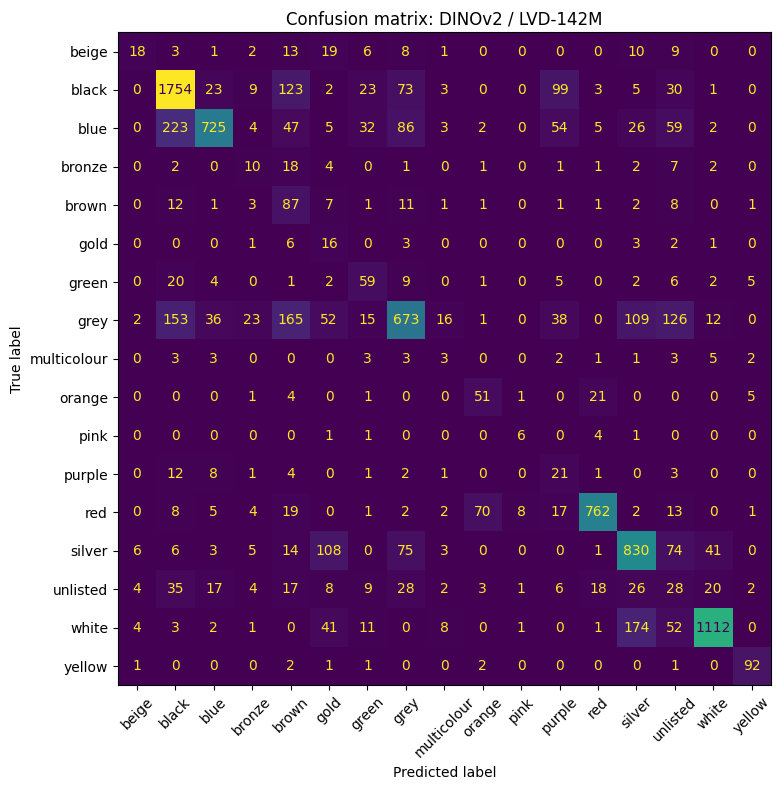

              precision    recall  f1-score   support

       beige     0.5143    0.2000    0.2880        90
       black     0.7851    0.8166    0.8005      2148
        blue     0.8756    0.5695    0.6901      1273
      bronze     0.1471    0.2041    0.1709        49
       brown     0.1673    0.6350    0.2648       137
        gold     0.0602    0.5000    0.1074        32
       green     0.3598    0.5086    0.4214       116
        grey     0.6910    0.4736    0.5620      1421
 multicolour     0.0698    0.1034    0.0833        29
      orange     0.3864    0.6071    0.4722        84
        pink     0.3529    0.4615    0.4000        13
      purple     0.0861    0.3889    0.1409        54
         red     0.9304    0.8337    0.8794       914
      silver     0.6957    0.7118    0.7037      1166
    unlisted     0.0665    0.1228    0.0863       228
       white     0.9282    0.7887    0.8528      1410
      yellow     0.8519    0.9200    0.8846       100

    accuracy              

In [68]:
best_preds = best_metrics["preds"]
best_targets = best_metrics["targets"]
cm = confusion_matrix(best_targets, best_preds)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f"Confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

print(classification_report(best_targets, best_preds, target_names=class_names, digits=4))


## Вывод

В работе были сравнены ResNet18 на ImageNet, DINOv2 не на ImageNet, и самописанная CNN, обученная с нуля. Лучший результат по F1_macro показала DINOv2, что говорит о том, что она имеет преимущество более сильного предобучения для данной задачи

Качество по классам распределено неравномерно, тк значение F1_macro оказалось заметно ниже accuracy, поэтому модель лучше распознаёт частые цвета и хуже справляется с редкими. Основные ошибки возникают между близкими оттенками, например grey, silver, white и black

В целом предобученные модели показали качество немного выше, чем сеть, обученная с нуля